1. Import library yang dibutuhin 

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


2. Ambil data

In [24]:
file_path = 'spam.csv'

try:
    # Try reading with 'utf-8' first, then 'latin1' or 'ISO-8859-1' if that fails
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        print("UTF-8 decoding failed, trying 'latin1'...")
        df = pd.read_csv(file_path, encoding='latin1')

    print("Dataset loaded successfully!")
    print("\nDataset Information:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

UTF-8 decoding failed, trying 'latin1'...
Dataset loaded successfully!

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


3. EDA ( Exploratory Data analysis)

In [25]:
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

print("\nMissing Values:")
display(df.isnull().sum())

print("\nUnique values in 'v1' column (if applicable):")
if 'v1' in df.columns:
    print(df['v1'].value_counts())
else:
    print("'v1' column not found.")

print("\nUnique values in 'v2' column (if applicable):")
if 'v2' in df.columns:
    print(df['v2'].head())
else:
    print("'v2' column not found.")


Descriptive Statistics:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2



Missing Values:


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


Unique values in 'v1' column (if applicable):
v1
ham     4825
spam     747
Name: count, dtype: int64

Unique values in 'v2' column (if applicable):
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: v2, dtype: str


4. Proses

In [26]:
import re

df_cleaned = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')
df_cleaned = df_cleaned.rename(columns={'v1': 'label', 'v2': 'message'})

# Tambahkan kolom panjang pesan
df_cleaned['message_length'] = df_cleaned['message'].apply(len)

def clean_text(text):
    text = str(text).lower() # 1. Mengubah teks menjadi huruf kecil semua
    text = re.sub(r'[^a-z\s]', '', text) # 2. Menghapus tanda baca dan angka
    text = re.sub(r'\s+', ' ', text).strip() # 3. Menghapus spasi berlebih
    return text

# Terapkan pembersihan dan buat kolom baru
df_cleaned['clean_message'] = df_cleaned['message'].apply(clean_text)
# --------------------------------------

print("Dataset setelah dibersihkan dan diproses:")
display(df_cleaned[['label', 'message', 'clean_message']].head())

Dataset setelah dibersihkan dan diproses:


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


5.  Vectorisasi..? dari teks ke angka

In [27]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_cleaned['clean_message'])

print("Bentuk matriks TF-IDF:", tfidf_matrix.shape)
print("Contoh fitur (kata-kata) yang digunakan:", tfidf_vectorizer.get_feature_names_out()[:20])

Bentuk matriks TF-IDF: (5572, 5000)
Contoh fitur (kata-kata) yang digunakan: ['aah' 'aaniye' 'aathilove' 'aathiwhere' 'abi' 'ability' 'abiola' 'abj'
 'able' 'abroad' 'absence' 'absolutely' 'abstract' 'abt' 'abta' 'aburo'
 'abusers' 'ac' 'academic' 'acc']


6. Train-Test Split (Membagi Data Latih dan Uji)

In [28]:
# Pisahkan fitur (X) dan target label (y)
X = tfidf_matrix
y = df_cleaned['label']

# Membagi data: 80% untuk training, 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah data latih (Training):", X_train.shape[0])
print("Jumlah data uji (Testing):", X_test.shape[0])


Jumlah data latih (Training): 4457
Jumlah data uji (Testing): 1115


7. Model 1: Linear SVM (Support Vector Machine)

--- Evaluasi Linear SVM ---
Akurasi: 0.9757847533632287

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.97      0.85      0.90       150

    accuracy                           0.98      1115
   macro avg       0.97      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



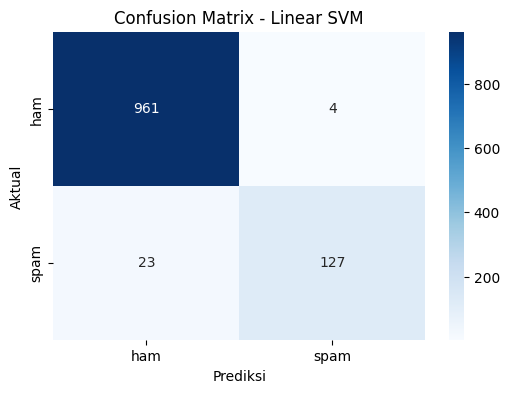

In [29]:
# Inisialisasi dan latih model Linear SVC
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
svm_predictions = svm_model.predict(X_test)

# Evaluasi
print("--- Evaluasi Linear SVM ---")
print("Akurasi:", accuracy_score(y_test, svm_predictions))
print("\nClassification Report:\n", classification_report(y_test, svm_predictions))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, svm_predictions), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


8. Model 2: Logistic Regression

--- Evaluasi Logistic Regression ---
Akurasi: 0.9506726457399103

Classification Report:
               precision    recall  f1-score   support

         ham       0.95      1.00      0.97       965
        spam       0.97      0.65      0.78       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



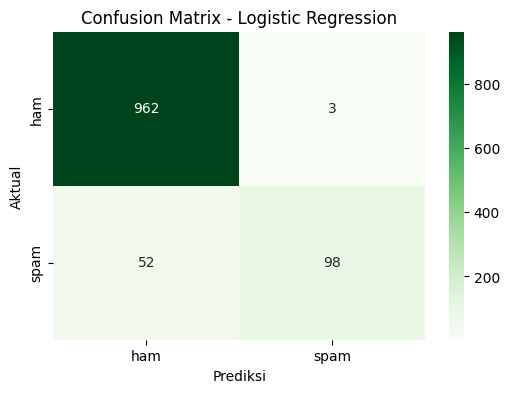

In [30]:
# Inisialisasi dan latih model Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
lr_predictions = lr_model.predict(X_test)

# Evaluasi
print("--- Evaluasi Logistic Regression ---")
print("Akurasi:", accuracy_score(y_test, lr_predictions))
print("\nClassification Report:\n", classification_report(y_test, lr_predictions))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_predictions), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


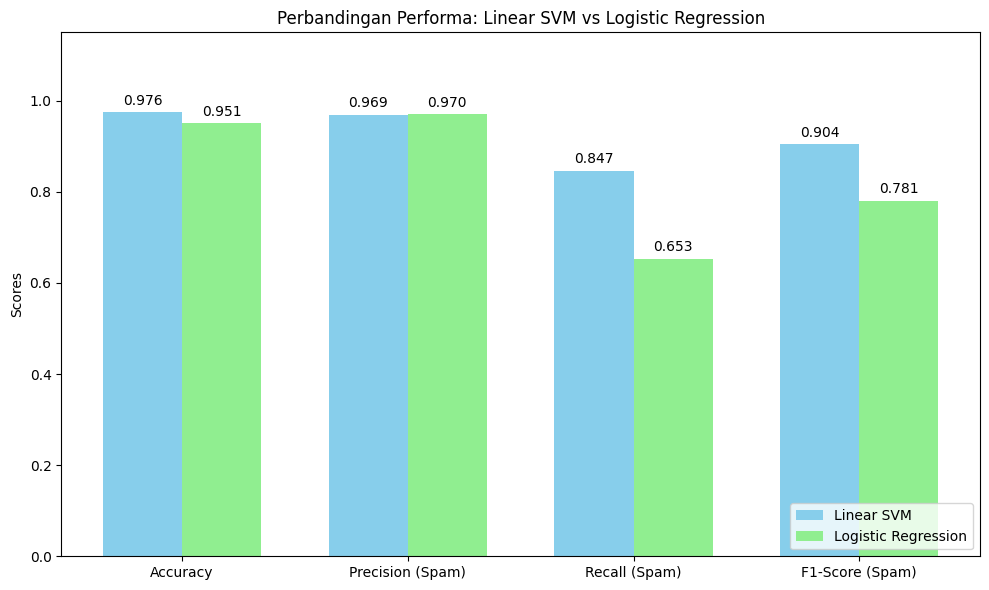

In [31]:
# 10. Perbandingan Performa Model dalam Satu Grafik
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Menghitung metrik SVM
svm_acc = accuracy_score(y_test, svm_predictions)
svm_prec, svm_rec, svm_f1, _ = precision_recall_fscore_support(y_test, svm_predictions, pos_label='spam', average='binary')

# Menghitung metrik untuk Logistic Regression
lr_acc = accuracy_score(y_test, lr_predictions)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(y_test, lr_predictions, pos_label='spam', average='binary')

# Data untuk plot
metrics = ['Accuracy', 'Precision (Spam)', 'Recall (Spam)', 'F1-Score (Spam)']
svm_scores = [svm_acc, svm_prec, svm_rec, svm_f1]
lr_scores = [lr_acc, lr_prec, lr_rec, lr_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, svm_scores, width, label='Linear SVM', color='skyblue')
rects2 = ax.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='lightgreen')

# Menambahkan teks dan label
ax.set_ylabel('Scores')
ax.set_title('Perbandingan Performa: Linear SVM vs Logistic Regression')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')

# Menambahkan nilai di atas bar
ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.show()


9. Kesimpulan

- Kedua model Supervised Learning (Linear SVM dan Logistic Regression) memberikan hasil akurasi yang sangat tinggi (diatas 95%) dibandingkan dengan metode Unsupervised.
- Linear SVM fokusnya pada pencarian margin/batas paling tegas antara kelas Spam dan Ham.
- Logistic Regression menggunakan pendekatan probabilitas matematis.
- Untuk klasifikasi teks TF-IDF yang berdimensi besar dan tersebar jauh (sparse), model linear adalah standar industri dan pilihan yang jauh lebih tepat dan efisien.

Serta lebih baik Linear SVM berbeda tipis dengan logistik dalam pengolahan datanya
